# TTRPG EDA — Exploratory Data Analysis
## Optimizing Board Game Discovery Through Text Vectorization and Representative Clustering

**By:** Santiago, Uy, Angos, Araña, Ramirez  
**Program:** BS Data Science — Asian Institute of Management

---

### Purpose of This Notebook

This notebook is the EDA for the **TTRPG (Tabletop Role-Playing Games)** dataset scraped from RPGGeek. It is the companion to the BGG board game EDA notebook — together, these two 10k-game datasets form the full 20k-game corpus used in the modeling and clustering phases.

**What this notebook covers:**
1. Dataset loading, validation, and cleaning
2. Handling missing labels (unrated games with 0 reviews)
3. Score distribution analysis and comparison with BGG
4. Class imbalance investigation
5. Review count analysis — reliability of scores
6. Publishing year trends
7. Text description analysis
8. Extreme cases (top & bottom games)

**Key difference from BGG dataset:** This dataset includes `Number of Reviews` and `Publishing Year` columns, and contains **unrated games** (score = 0, reviews = 0) whose scores will be **predicted** by the model rather than imputed.

**Charts are exported at 300 DPI** to the `eda_charts/` folder.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import re
import html as html_mod
import os

# Create output folder for chart exports
os.makedirs('eda_charts', exist_ok=True)

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print('Libraries loaded!')

Libraries loaded!


---
## 1. Load and Validate the Dataset

### Thought Process

Unlike the BGG dataset (which was pre-cleaned), the TTRPG dataset was scraped independently from RPGGeek. We need to check for:
- **Missing values** and **zero-score entries** (games with no ratings)
- **Data types** — especially `Publishing Year` which may contain bad values
- **Scale and structure** — how it compares to the BGG dataset

In [24]:
df_raw = pd.read_csv('../marc/ttrpg_database_final.csv')

print(f'Dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'\n=== Data Types ===')
print(df_raw.dtypes)
print(f'\n=== Missing Values (nulls) ===')
print(df_raw.isnull().sum())
print(f'\n=== First 5 Rows ===')
df_raw.head()

Dataset shape: (10000, 5)
Columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Publishing Year']

=== Data Types ===
Name                  object
Description           object
Average Score        float64
Number of Reviews      int64
Publishing Year        int64
dtype: object

=== Missing Values (nulls) ===
Name                 0
Description          0
Average Score        0
Number of Reviews    0
Publishing Year      0
dtype: int64

=== First 5 Rows ===


,Name,Description,Average Score,Number of Reviews,Publishing Year
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,2014
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,2004
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,1981
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,2013
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,1988


---
## 2. Handling Missing Labels (Unrated Games)

### Thought Process

While there are zero null values, many games have `Average Score = 0` and `Number of Reviews = 0`. These are **unrated games** — they exist on RPGGeek but no one has reviewed them yet. A score of 0 doesn't mean the game is terrible; it means there's no data.

**Decision:** We do **not** impute these scores. Instead, they will be **predicted** by the trained model after it learns from the rated games. Given the dataset size (~20k total across BGG + RPGG), this is viable.

For the EDA, we split the data:
- `df` — rated games only (used for all score-related analysis)
- `df_unrated` — unrated games (kept for description analysis and future prediction)

In [25]:
# Identify unrated games
unrated_mask = (df_raw['Average Score'] == 0) & (df_raw['Number of Reviews'] == 0)

df_unrated = df_raw[unrated_mask].copy()
df = df_raw[~unrated_mask].copy()

print(f'Total games:   {len(df_raw):,}')
print(f'Rated games:   {len(df):,} ({len(df)/len(df_raw)*100:.1f}%)')
print(f'Unrated games: {len(df_unrated):,} ({len(df_unrated)/len(df_raw)*100:.1f}%) — to be predicted')

# Also fix bad publishing years (year 0)
bad_years = df['Publishing Year'] == 0
print(f'\nBad publishing years (year=0): {bad_years.sum()}')
if bad_years.sum() > 0:
    df.loc[bad_years, 'Publishing Year'] = np.nan
    print('  -> Set to NaN (will exclude from year-based analysis)')

print(f'\n=== Rated Games — Score Stats ===')
print(df['Average Score'].describe().round(4))

Total games:   10,000
Rated games:   9,021 (90.2%)
Unrated games: 979 (9.8%) — to be predicted

Bad publishing years (year=0): 2
  -> Set to NaN (will exclude from year-based analysis)

=== Rated Games — Score Stats ===
count    9021.0000
mean        7.0780
std         1.0878
min         1.0000
25%         6.5000
50%         7.1250
75%         7.7500
max        10.0000
Name: Average Score, dtype: float64


---
## 3. Score Distribution

### Thought Process

Same question as the BGG EDA: what does the target variable look like? How does the TTRPG score distribution compare to BGG's? Key things to check:
- Is it roughly normal like BGG (centered ~6.6)?
- Is the spread wider or narrower?
- Are there scoring patterns unique to RPGGeek?

In [26]:
# Summary statistics
print('=== Average Score Statistics (Rated Games Only) ===')
print(df['Average Score'].describe().round(4))
print(f'\nSkewness: {df["Average Score"].skew():.4f}')
print(f'Kurtosis: {df["Average Score"].kurtosis():.4f}')
print(f'\nComparison with BGG dataset:')
print(f'  BGG:  mean=6.60, std=0.81, min=1.16, max=8.97')
print(f'  RPGG: mean={df["Average Score"].mean():.2f}, std={df["Average Score"].std():.2f}, '
      f'min={df["Average Score"].min():.2f}, max={df["Average Score"].max():.2f}')

=== Average Score Statistics (Rated Games Only) ===
count    9021.0000
mean        7.0780
std         1.0878
min         1.0000
25%         6.5000
50%         7.1250
75%         7.7500
max        10.0000
Name: Average Score, dtype: float64

Skewness: -0.7988
Kurtosis: 3.0152

Comparison with BGG dataset:
  BGG:  mean=6.60, std=0.81, min=1.16, max=8.97
  RPGG: mean=7.08, std=1.09, min=1.00, max=10.00


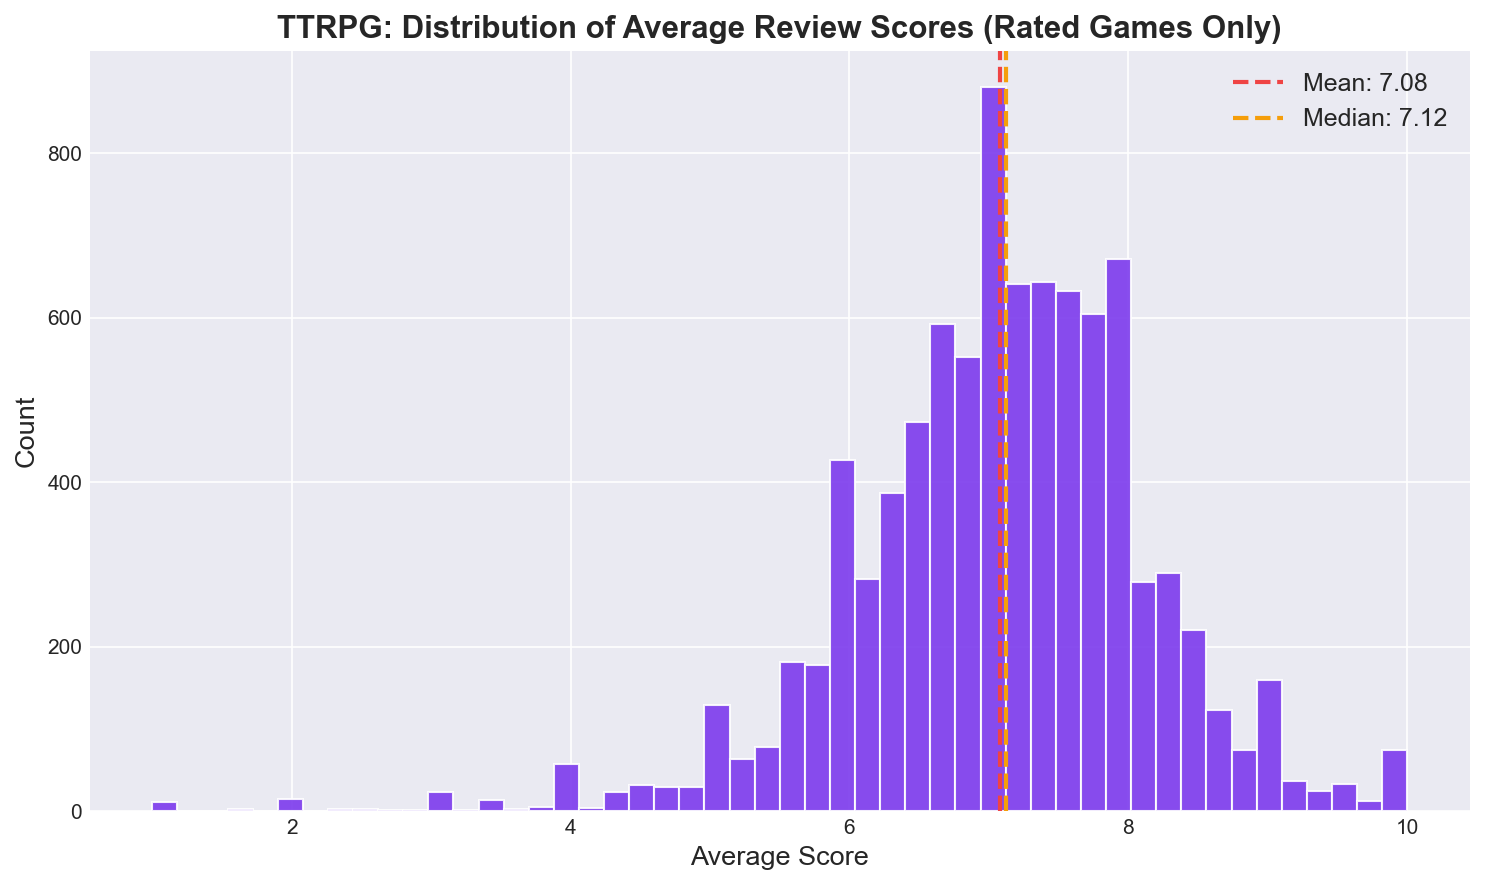

In [27]:
# CHART T01: Score Distribution Histogram
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['Average Score'], bins=50, color='#7C3AED', edgecolor='white', alpha=0.9)
ax.axvline(df['Average Score'].mean(), color='#EF4444', linestyle='--', linewidth=2, 
           label=f'Mean: {df["Average Score"].mean():.2f}')
ax.axvline(df['Average Score'].median(), color='#F59E0B', linestyle='--', linewidth=2, 
           label=f'Median: {df["Average Score"].median():.2f}')

ax.set_xlabel('Average Score', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('TTRPG: Distribution of Average Review Scores (Rated Games Only)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('eda_charts/T01_ttrpg_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 1: TTRPG Scores Have a Wider Spread Than BGG

**Observations:**
- The TTRPG dataset has a noticeably wider standard deviation compared to BGG (which has std=0.81)
- There's a longer left tail — more very low-scoring games
- The distribution may be more left-skewed than BGG

**Why this matters:** The wider spread means the 10-point ordinal scale should still work well here. Games with very few reviews may have more extreme scores (we'll check this in the review count analysis).

---
## 4. Class Distribution (Hit / Average / Flop)

### Thought Process

Using the same labeling as the BGG notebook to enable comparison. Is the TTRPG dataset similarly imbalanced?

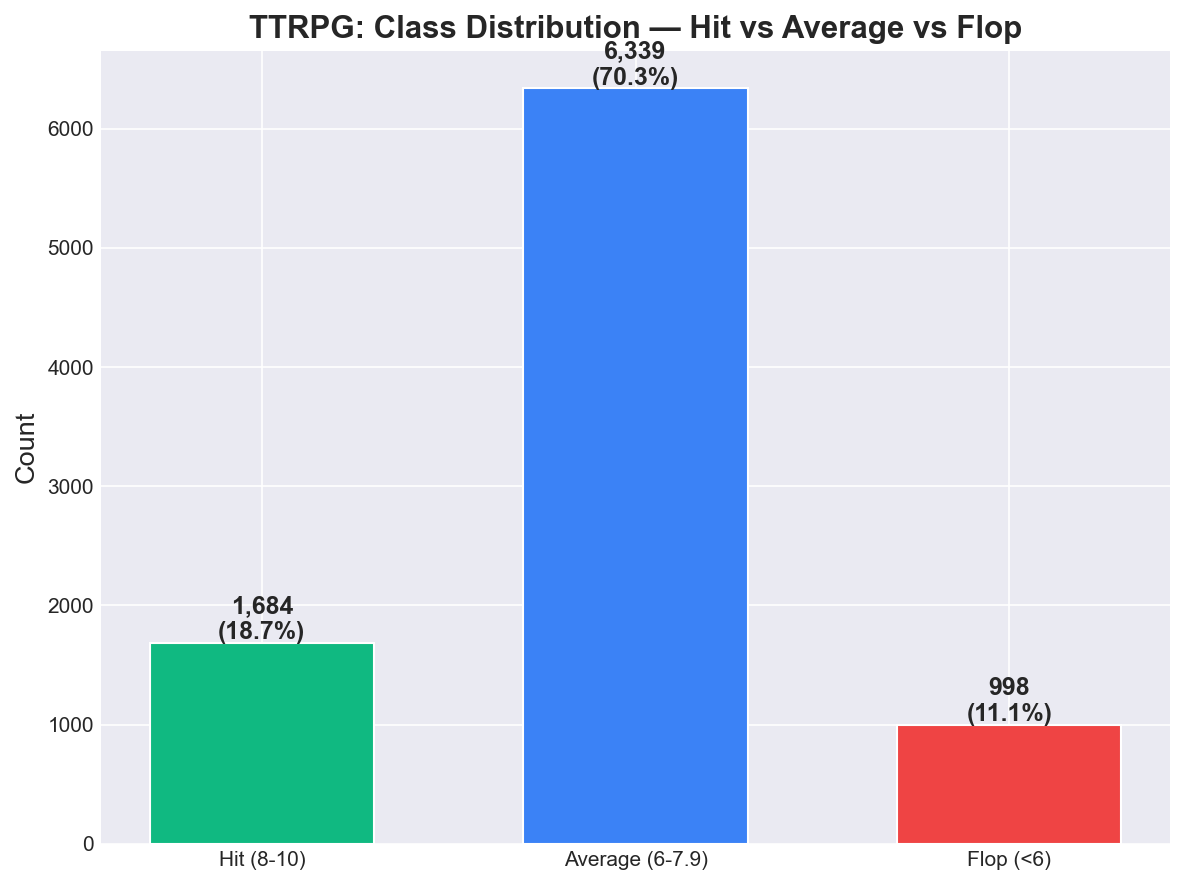

Class breakdown:
  Hit (8-10): 1,684 (18.7%)
  Average (6-7.9): 6,339 (70.3%)
  Flop (<6): 998 (11.1%)

Comparison with BGG:
  BGG:  Hit=340 (3.4%), Average=7608 (76.1%), Flop=2052 (20.5%)


In [28]:
# Create labels (same bins as BGG)
def label_game(score):
    if score >= 8.0:
        return 'Hit (8-10)'
    elif score >= 6.0:
        return 'Average (6-7.9)'
    else:
        return 'Flop (<6)'

df['label'] = df['Average Score'].apply(label_game)

# CHART T02: Class Distribution
fig, ax = plt.subplots(figsize=(8, 6))

labels_order = ['Hit (8-10)', 'Average (6-7.9)', 'Flop (<6)']
counts = [df[df['label'] == l].shape[0] for l in labels_order]
colors = ['#10B981', '#3B82F6', '#EF4444']

bars = ax.bar(labels_order, counts, color=colors, edgecolor='white', width=0.6)
for bar, count in zip(bars, counts):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Count', fontsize=13)
ax.set_title('TTRPG: Class Distribution — Hit vs Average vs Flop', 
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/T02_ttrpg_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Class breakdown:')
for label in labels_order:
    count = (df['label'] == label).sum()
    print(f'  {label}: {count:,} ({count/len(df)*100:.1f}%)')

print(f'\nComparison with BGG:')
print(f'  BGG:  Hit=340 (3.4%), Average=7608 (76.1%), Flop=2052 (20.5%)')

---
## 5. The 10-Point Ordinal Scale

### Thought Process

We adopted the 10-point scale for BGG because the 3-class split was too imbalanced. Does the same logic apply to TTRPG data?

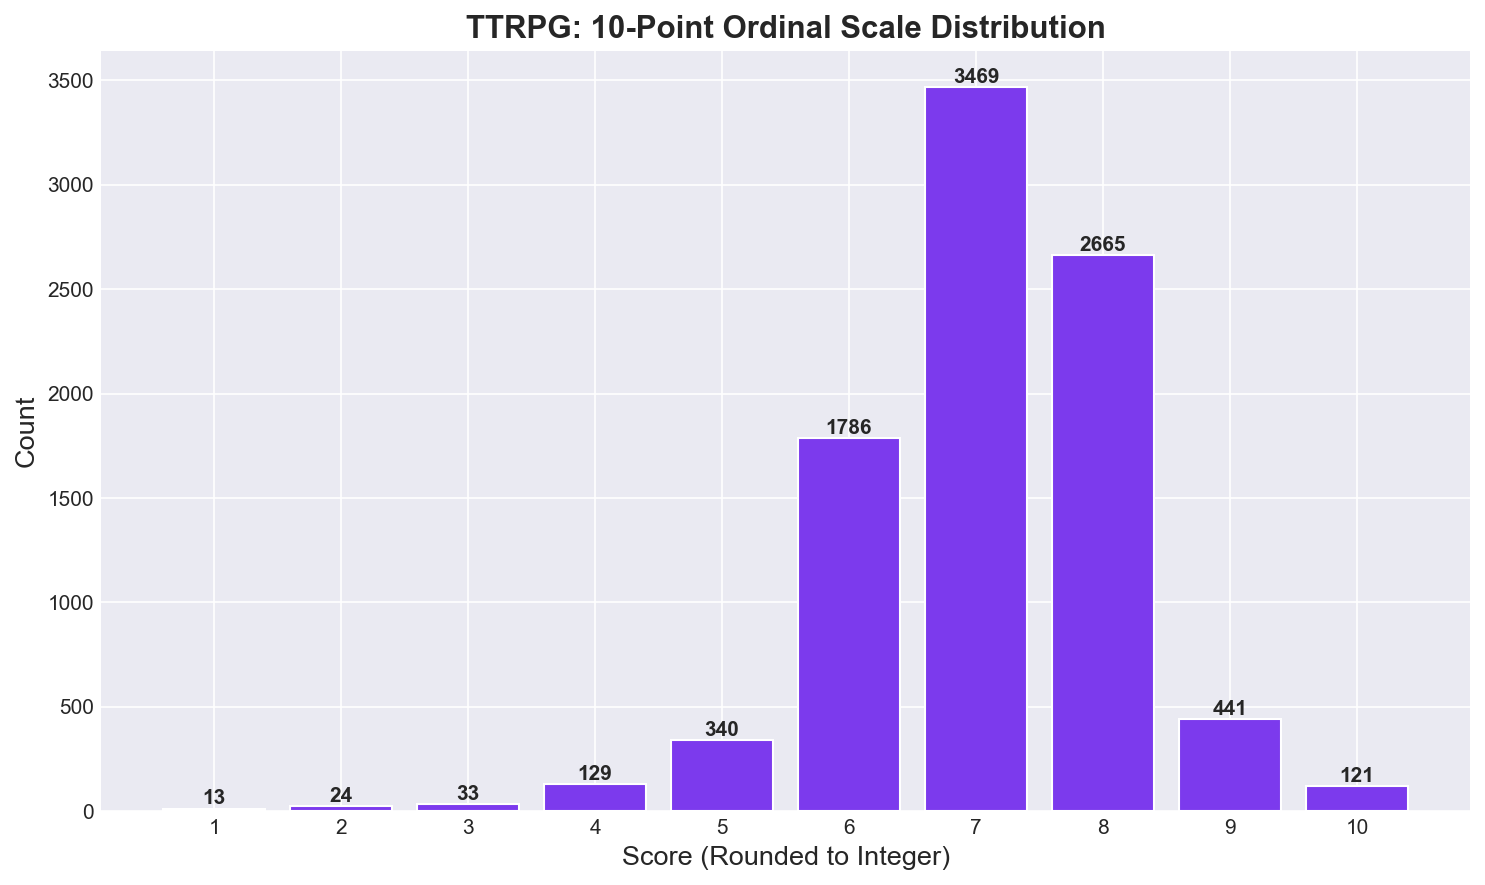

10-point baseline accuracy: 0.2786


In [29]:
# 10-point ordinal scale
df['score_10pt'] = df['Average Score'].round().astype(int)
# Clip to 1-10 range (some rounding might create 0 or 11)
df['score_10pt'] = df['score_10pt'].clip(1, 10)

# CHART T03: 10-Point Ordinal Distribution
fig, ax = plt.subplots(figsize=(10, 6))

bin_counts = df['score_10pt'].value_counts().sort_index()
ax.bar(bin_counts.index, bin_counts.values, color='#7C3AED', edgecolor='white')

for idx, val in bin_counts.items():
    ax.text(idx, val + 20, str(val), ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Score (Rounded to Integer)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('TTRPG: 10-Point Ordinal Scale Distribution', fontsize=15, fontweight='bold')
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig('eda_charts/T03_ttrpg_10point_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Baseline accuracy
props = df['score_10pt'].value_counts(normalize=True)
baseline_acc = (props ** 2).sum()
print(f'10-point baseline accuracy: {baseline_acc:.4f}')

---
## 6. Review Count Analysis — Score Reliability

### Thought Process

The TTRPG dataset includes `Number of Reviews`, which the BGG dataset does not. This lets us investigate:
- Do games with fewer reviews have more extreme/unreliable scores?
- Is there a minimum review threshold below which scores are noise?
- How does review count relate to score?

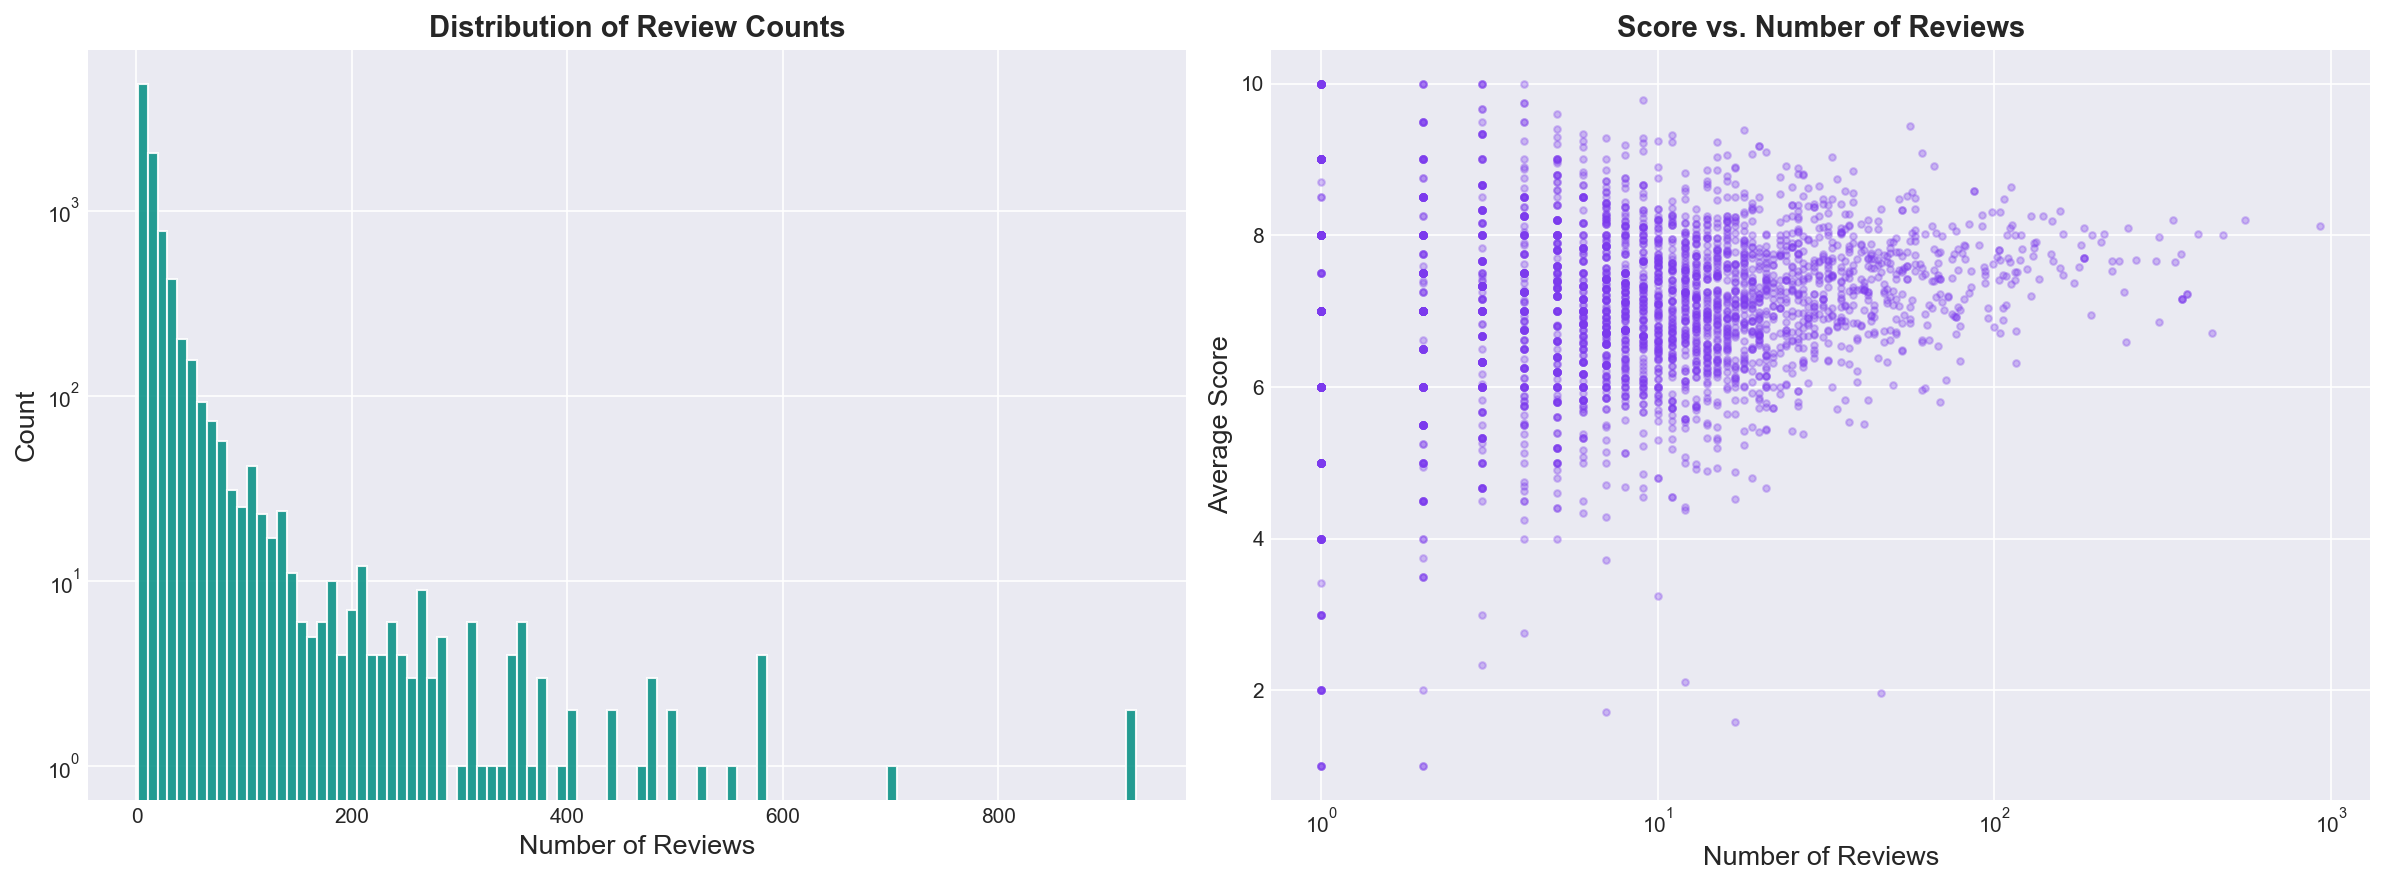

Score statistics by review count bracket:
     Reviews   Count    Mean     Std    Min    Max
    1-5       2,735    6.96    1.49   1.00  10.00
    6-15      3,513    7.02    0.90   1.43   9.83
   16-50      2,144    7.20    0.77   1.59   9.67
   51-100       374    7.41    0.64   5.42   9.44
  101-1000      255    7.61    0.53   5.81   8.97


In [30]:
# CHART T04: Review Count Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full distribution (log scale)
axes[0].hist(df['Number of Reviews'], bins=100, color='#0D9488', edgecolor='white', alpha=0.9)
axes[0].set_xlabel('Number of Reviews', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Distribution of Review Counts', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')

# Right: score vs review count scatter
sample = df.sample(min(3000, len(df)), random_state=42)
axes[1].scatter(sample['Number of Reviews'], sample['Average Score'], 
                alpha=0.3, s=10, color='#7C3AED')
axes[1].set_xlabel('Number of Reviews', fontsize=13)
axes[1].set_ylabel('Average Score', fontsize=13)
axes[1].set_title('Score vs. Number of Reviews', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('eda_charts/T04_ttrpg_reviews_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Score reliability by review brackets
brackets = [(1, 5), (6, 15), (16, 50), (51, 100), (101, 1000)]
print('Score statistics by review count bracket:')
print(f'{"Reviews":>12s}  {"Count":>6s}  {"Mean":>6s}  {"Std":>6s}  {"Min":>5s}  {"Max":>5s}')
for low, high in brackets:
    subset = df[(df['Number of Reviews'] >= low) & (df['Number of Reviews'] <= high)]
    if len(subset) > 0:
        print(f'{low:>5d}-{high:<5d}  {len(subset):>6,}  '
              f'{subset["Average Score"].mean():>6.2f}  {subset["Average Score"].std():>6.2f}  '
              f'{subset["Average Score"].min():>5.2f}  {subset["Average Score"].max():>5.2f}')

### Finding: Low-Review Games Have Unreliable Scores

**Observations:**
- Games with very few reviews (1–5) have a much wider score spread
- As review count increases, scores converge toward the 6–8 range
- This is classic small-sample-size noise

**Why this matters for modeling:** When we merge BGG and TTRPG data for clustering, the model will need to handle these noisy scores. The TF-IDF features from descriptions should be more stable than the review-based scores for low-review games.

---
## 7. Publishing Year Trends

### Thought Process

Another column unique to this dataset. Questions:
- When were most TTRPGs published?
- Are newer games rated higher or lower?
- Is there a golden age of TTRPGs?

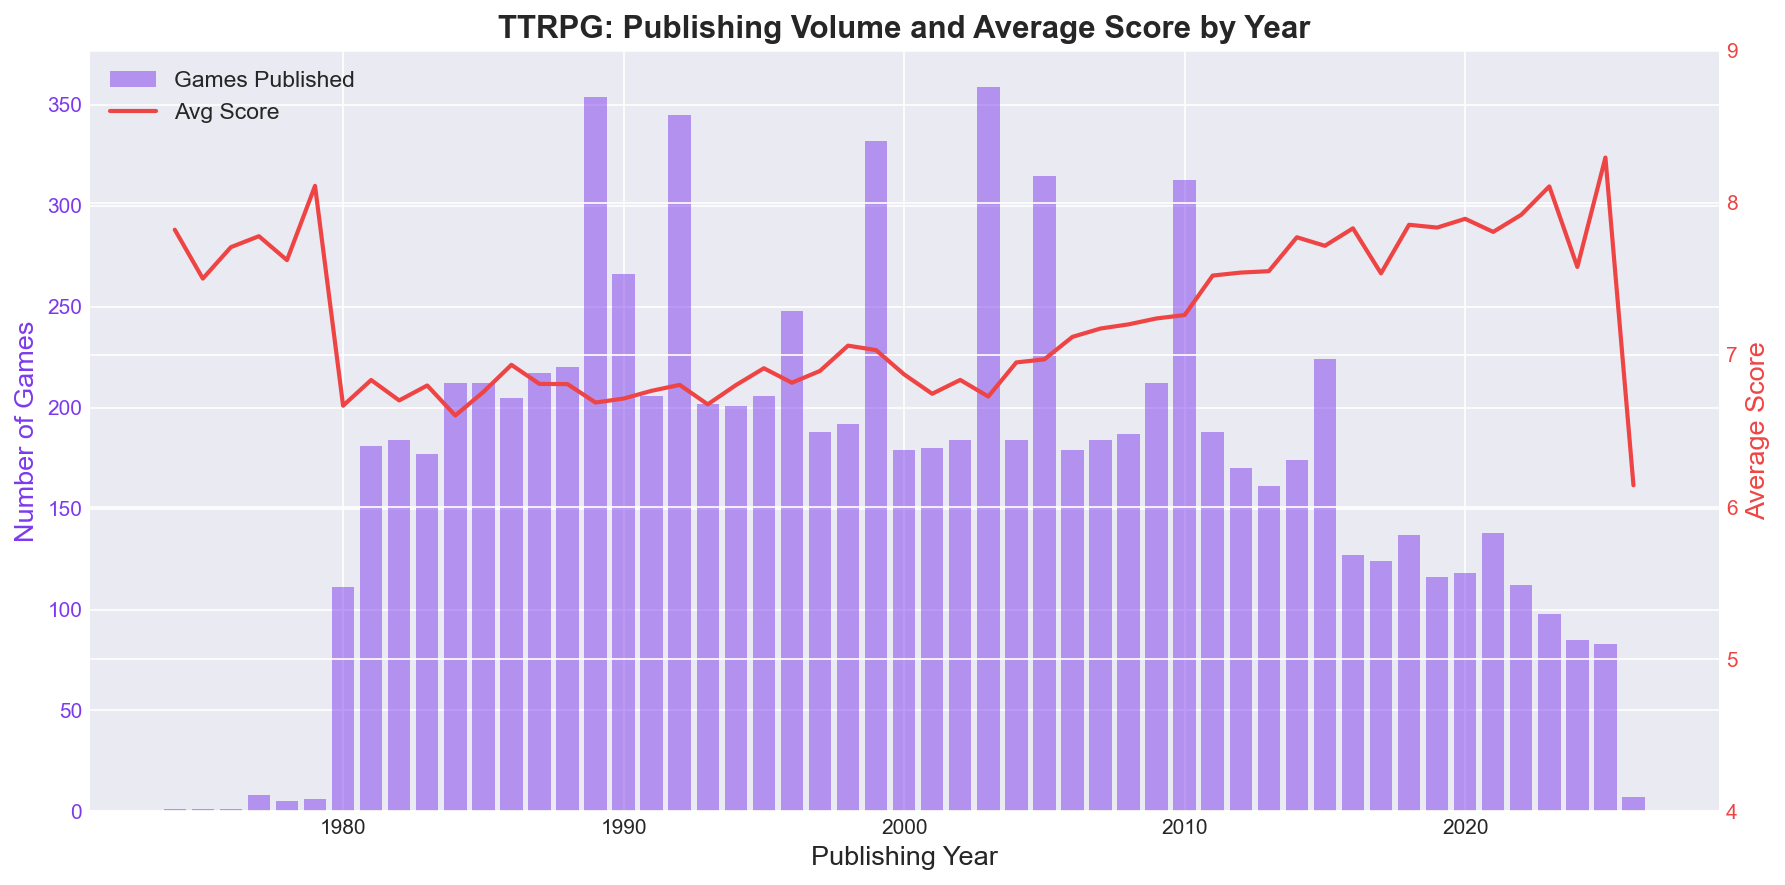

Year range: 1974 - 2026
Peak year: 2003 (359 games)


In [31]:
# Filter to valid years
df_years = df[df['Publishing Year'].notna() & (df['Publishing Year'] >= 1970)].copy()
df_years['Publishing Year'] = df_years['Publishing Year'].astype(int)

# CHART T05: Games per Year + Average Score by Year
fig, ax1 = plt.subplots(figsize=(12, 6))

year_counts = df_years['Publishing Year'].value_counts().sort_index()
year_means = df_years.groupby('Publishing Year')['Average Score'].mean()

# Bar: games per year
ax1.bar(year_counts.index, year_counts.values, color='#7C3AED', alpha=0.5, label='Games Published')
ax1.set_xlabel('Publishing Year', fontsize=13)
ax1.set_ylabel('Number of Games', fontsize=13, color='#7C3AED')
ax1.tick_params(axis='y', labelcolor='#7C3AED')

# Line: average score by year
ax2 = ax1.twinx()
ax2.plot(year_means.index, year_means.values, color='#EF4444', linewidth=2, label='Avg Score')
ax2.set_ylabel('Average Score', fontsize=13, color='#EF4444')
ax2.tick_params(axis='y', labelcolor='#EF4444')
ax2.set_ylim(4, 9)

ax1.set_title('TTRPG: Publishing Volume and Average Score by Year', 
              fontsize=15, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('eda_charts/T05_ttrpg_year_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Year range: {df_years["Publishing Year"].min()} - {df_years["Publishing Year"].max()}')
print(f'Peak year: {year_counts.idxmax()} ({year_counts.max()} games)')

---
## 8. Text Description Analysis

### Thought Process

Same rationale as BGG: descriptions are the primary input to TF-IDF. We need to verify that TTRPG descriptions are long enough and contain discriminative vocabulary. Since this data will be **merged** with BGG for clustering, we also want to see how the vocabulary differs.

In [32]:
# Text feature engineering (same cleaning as BGG notebook)
def clean_text(text):
    text = html_mod.unescape(str(text))
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_desc'] = df['Description'].apply(clean_text)
df['word_count'] = df['clean_desc'].apply(lambda x: len(x.split()))

print('=== Description Length Statistics ===')
print(f'Mean word count:   {df["word_count"].mean():.0f} words')
print(f'Median word count: {df["word_count"].median():.0f} words')
print(f'Min word count:    {df["word_count"].min()} words')
print(f'Max word count:    {df["word_count"].max()} words')
print(f'\nComparison with BGG:')
print(f'  BGG:  mean=207, median=173')

=== Description Length Statistics ===
Mean word count:   151 words
Median word count: 131 words
Min word count:    3 words
Max word count:    1588 words

Comparison with BGG:
  BGG:  mean=207, median=173


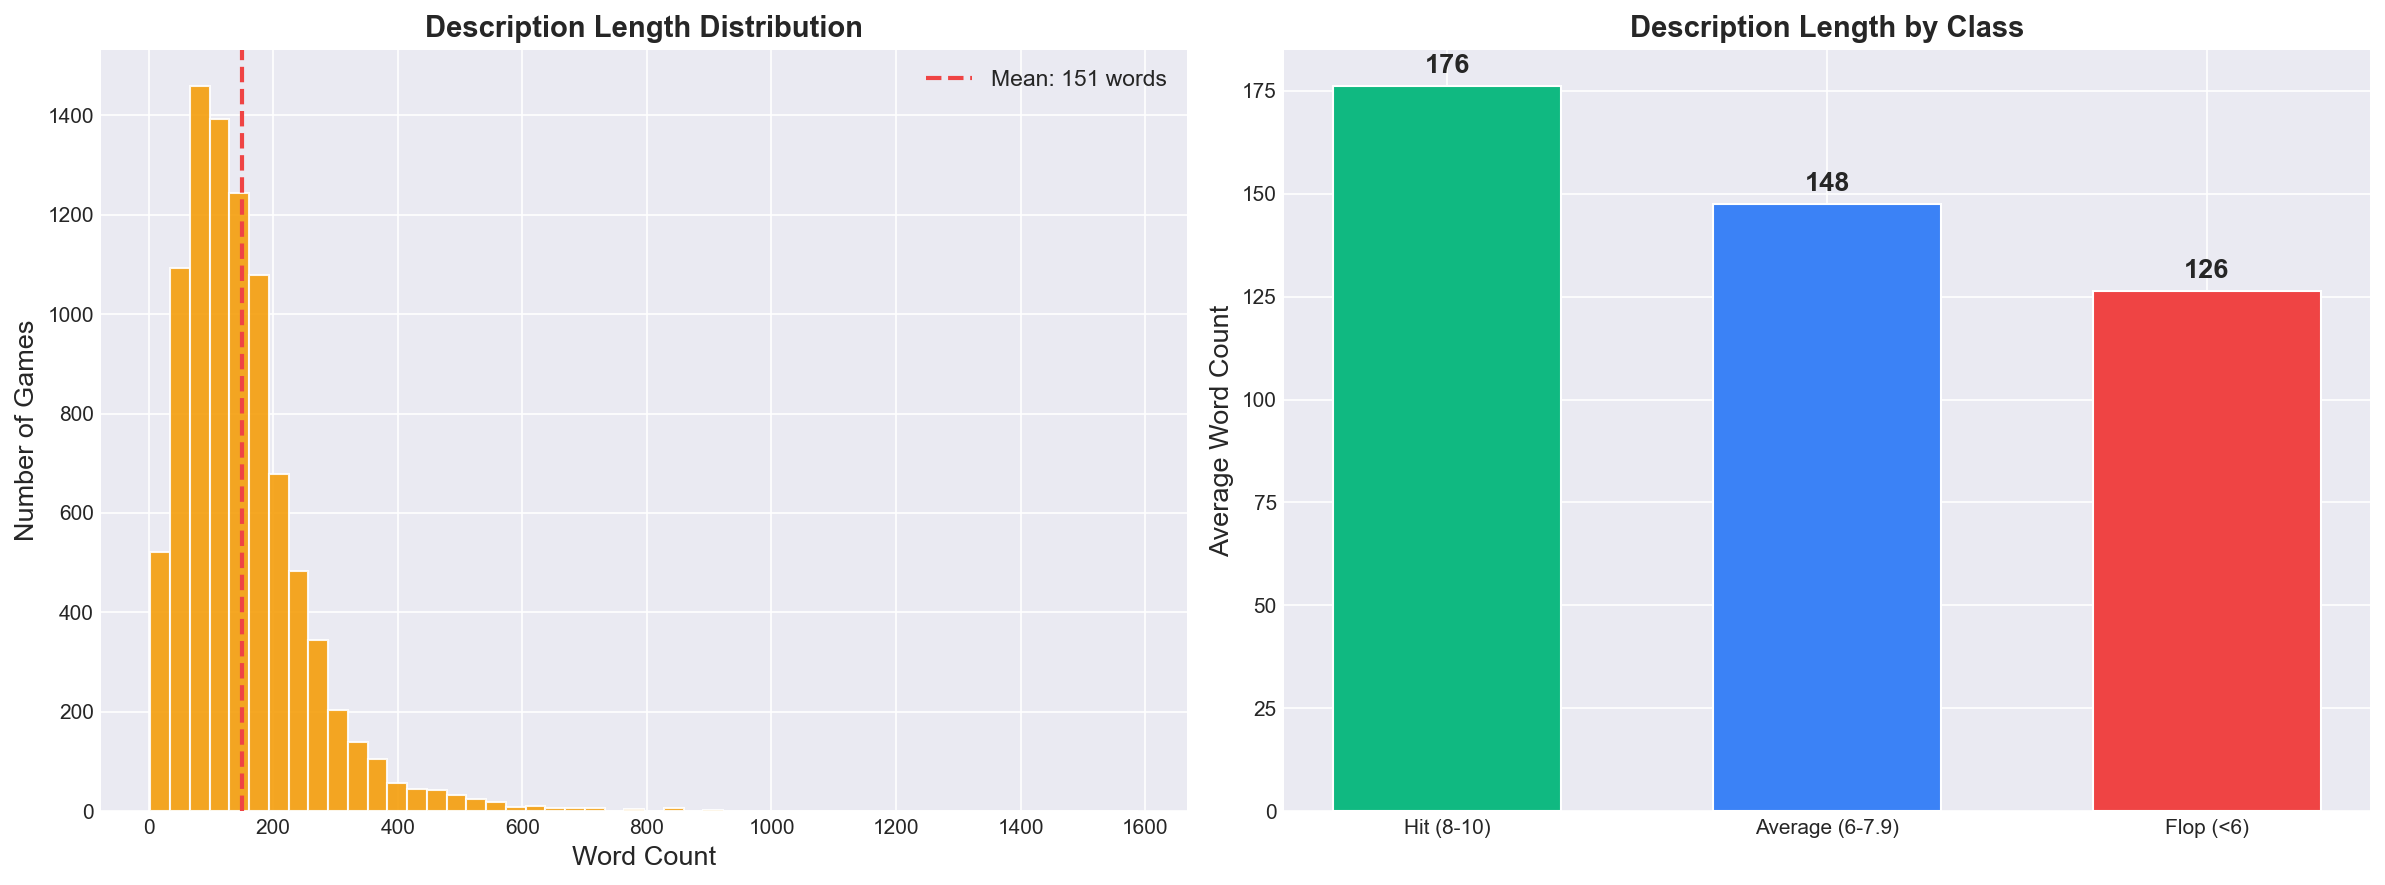

In [33]:
# CHART T06: Word Count Distribution + Word Count by Class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: word count histogram
axes[0].hist(df['word_count'], bins=50, color='#F59E0B', edgecolor='white', alpha=0.9)
axes[0].axvline(df['word_count'].mean(), color='#EF4444', linestyle='--', linewidth=2, 
               label=f'Mean: {df["word_count"].mean():.0f} words')
axes[0].set_xlabel('Word Count', fontsize=13)
axes[0].set_ylabel('Number of Games', fontsize=13)
axes[0].set_title('Description Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Right: avg word count by class
labels_order = ['Hit (8-10)', 'Average (6-7.9)', 'Flop (<6)']
colors = ['#10B981', '#3B82F6', '#EF4444']
means = [df[df['label'] == l]['word_count'].mean() for l in labels_order]
bars = axes[1].bar(labels_order, means, color=colors, edgecolor='white', width=0.6)
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                f'{m:.0f}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Word Count', fontsize=13)
axes[1].set_title('Description Length by Class', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/T06_ttrpg_wordcount_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

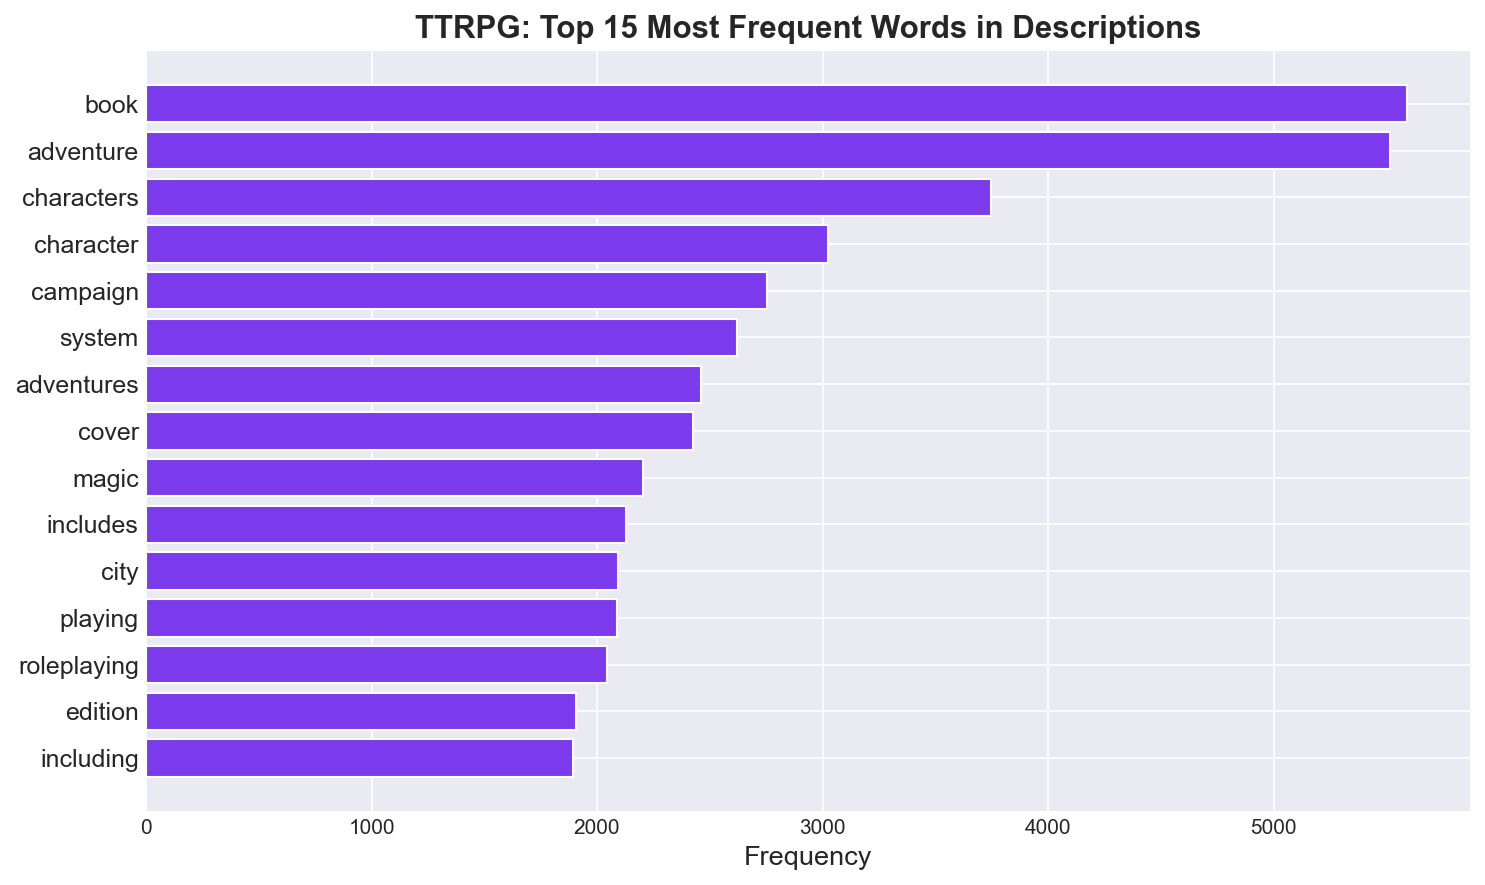

Top 15 words:
  book: 5,591
  adventure: 5,516
  characters: 3,745
  character: 3,024
  campaign: 2,752
  system: 2,622
  adventures: 2,459
  cover: 2,425
  magic: 2,204
  includes: 2,128
  city: 2,092
  playing: 2,087
  roleplaying: 2,043
  edition: 1,906
  including: 1,892


In [34]:
# Top words analysis
stopwords = set('''the a an and or but in on at to for of with by from is it that this are was were 
be been being have has had do does did will would could should may might can shall not no their they 
them he she his her its we our you your each all any some one two three four five more most other 
than then when which who what where how if as up out about into over after before between under 
again further there here also very just only own same so too such both few many much new old first 
last long great little man back even still way take come make like time get go see know need want 
use find give tell work call try ask put keep let set play run move live believe hold bring happen 
write provide sit stand lose pay meet include continue show next without enough well through during 
off down those these since while now per another every must upon game games player players card cards 
turn turns board piece pieces point points round rounds end different using used based order number 
place action actions hand rules rule side world team however able become part around made possible 
winning win won among sets takes taken starting started along across always already often usually 
sometimes never rather whether either neither yet least instead unless except within second third 
everything nothing something anything everyone anyone someone else'''.split())

all_words = ' '.join(df['clean_desc']).split()
filtered = [w for w in all_words if w not in stopwords and len(w) > 2]
word_freq = Counter(filtered).most_common(15)

# CHART T07: Top 15 Words
fig, ax = plt.subplots(figsize=(10, 6))
words, cnts = zip(*word_freq)
ax.barh(range(len(words)-1, -1, -1), cnts, color='#7C3AED', edgecolor='white')
ax.set_yticks(range(len(words)-1, -1, -1))
ax.set_yticklabels(words, fontsize=12)
ax.set_xlabel('Frequency', fontsize=13)
ax.set_title('TTRPG: Top 15 Most Frequent Words in Descriptions', 
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts/T07_ttrpg_top_words.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top 15 words:')
for word, count in word_freq:
    print(f'  {word}: {count:,}')

---
## 9. Top and Bottom Rated Games

### Thought Process

Looking at extreme cases to validate that RPGGeek scores reflect genuine quality signals. We filter to games with at least 10 reviews to avoid single-reviewer outliers.

Games with 10+ reviews: 4,521 out of 9,021


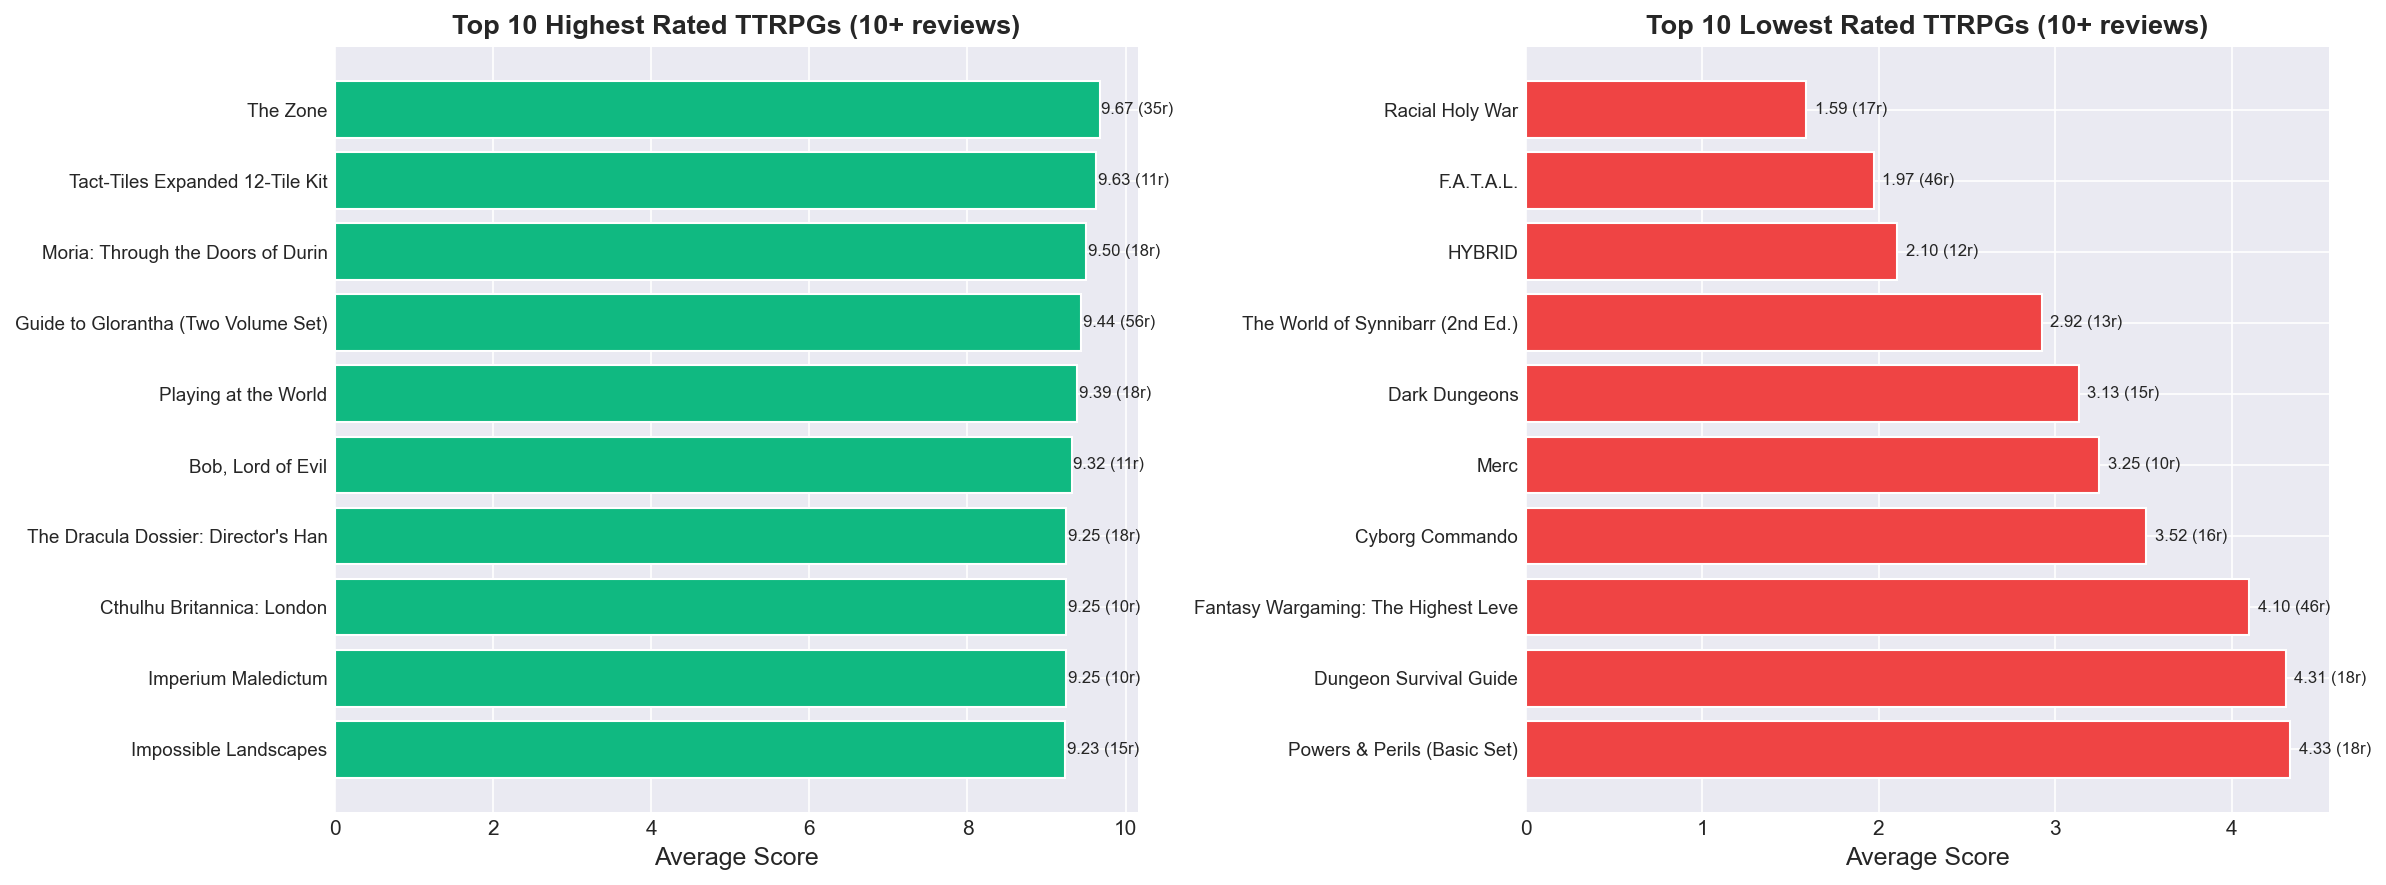

In [35]:
# Filter to reliable scores (10+ reviews)
df_reliable = df[df['Number of Reviews'] >= 10]
print(f'Games with 10+ reviews: {len(df_reliable):,} out of {len(df):,}')

# CHART T08: Top and Bottom Games
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = df_reliable.nlargest(10, 'Average Score')[['Name', 'Average Score', 'Number of Reviews']]
bot10 = df_reliable.nsmallest(10, 'Average Score')[['Name', 'Average Score', 'Number of Reviews']]

# Top 10
axes[0].barh(range(9, -1, -1), top10['Average Score'].values, color='#10B981', edgecolor='white')
axes[0].set_yticks(range(9, -1, -1))
axes[0].set_yticklabels([n[:35] for n in top10['Name'].values], fontsize=9)
axes[0].set_xlabel('Average Score', fontsize=12)
axes[0].set_title('Top 10 Highest Rated TTRPGs (10+ reviews)', fontsize=13, fontweight='bold')
for i, (_, row) in enumerate(top10.iterrows()):
    axes[0].text(row['Average Score'] + 0.02, 9 - i, 
                f'{row["Average Score"]:.2f} ({int(row["Number of Reviews"])}r)', 
                va='center', fontsize=8)

# Bottom 10
axes[1].barh(range(9, -1, -1), bot10['Average Score'].values, color='#EF4444', edgecolor='white')
axes[1].set_yticks(range(9, -1, -1))
axes[1].set_yticklabels([n[:35] for n in bot10['Name'].values], fontsize=9)
axes[1].set_xlabel('Average Score', fontsize=12)
axes[1].set_title('Top 10 Lowest Rated TTRPGs (10+ reviews)', fontsize=13, fontweight='bold')
for i, (_, row) in enumerate(bot10.iterrows()):
    axes[1].text(row['Average Score'] + 0.05, 9 - i, 
                f'{row["Average Score"]:.2f} ({int(row["Number of Reviews"])}r)', 
                va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_charts/T08_ttrpg_top_bottom_games.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 10. Summary: Key Findings and Comparison with BGG

| # | Finding | Comparison with BGG | Impact |
|---|---------|--------------------|---------|
| 1 | ~10% of games are unrated (score=0, reviews=0) | BGG had 0 missing values | Unrated games will be **predicted**, not imputed |
| 2 | Wider score spread than BGG | BGG std=0.81 | 10-point scale still viable |
| 3 | Low-review games have unreliable scores | BGG didn't include review counts | TF-IDF features more stable than scores for these games |
| 4 | Vocabulary is TTRPG-specific (character, adventure, edition) | BGG had cooperative, deckbuilding, campaign | Merged TF-IDF will capture genre-specific terms |
| 5 | Top-rated TTRPGs are recognized classics | BGG top games are hobby staples | RPGGeek scores are credible quality signals |

### Implications for Merging with BGG

When we merge these two datasets for clustering:
- The TF-IDF vocabulary will be richer (board game terms + TTRPG terms)
- TTRPGs and board games should naturally cluster apart due to distinct vocabulary
- Games with overlapping themes (e.g., fantasy dungeon crawlers vs fantasy TTRPGs) may cluster together — which is exactly what retailers want to see

In [36]:
print('=' * 60)
print('QUICK REFERENCE — TTRPG DATASET')
print('=' * 60)

print(f'\nDATASET')
print(f'  Total games:   {len(df_raw):,}')
print(f'  Rated games:   {len(df):,}')
print(f'  Unrated games: {len(df_unrated):,} (to be predicted)')
print(f'  Columns: Name, Description, Average Score, Number of Reviews, Publishing Year')

print(f'\nSCORE STATS (rated only)')
print(f'  Mean: {df["Average Score"].mean():.2f}')
print(f'  Median: {df["Average Score"].median():.2f}')
print(f'  Std Dev: {df["Average Score"].std():.2f}')
print(f'  Min: {df["Average Score"].min():.2f} | Max: {df["Average Score"].max():.2f}')

print(f'\nCLASS DISTRIBUTION')
for label in ['Hit (8-10)', 'Average (6-7.9)', 'Flop (<6)']:
    count = (df['label'] == label).sum()
    print(f'  {label}: {count:,} ({count/len(df)*100:.1f}%)')

print(f'\nDESCRIPTIONS')
print(f'  Mean word count:   {df["word_count"].mean():.0f} words')
print(f'  Median word count: {df["word_count"].median():.0f} words')

print(f'\nREVIEWS')
print(f'  Mean reviews:   {df["Number of Reviews"].mean():.1f}')
print(f'  Median reviews: {df["Number of Reviews"].median():.0f}')
print(f'  Max reviews:    {df["Number of Reviews"].max()}')

QUICK REFERENCE — TTRPG DATASET

DATASET
  Total games:   10,000
  Rated games:   9,021
  Unrated games: 979 (to be predicted)
  Columns: Name, Description, Average Score, Number of Reviews, Publishing Year

SCORE STATS (rated only)
  Mean: 7.08
  Median: 7.12
  Std Dev: 1.09
  Min: 1.00 | Max: 10.00

CLASS DISTRIBUTION
  Hit (8-10): 1,684 (18.7%)
  Average (6-7.9): 6,339 (70.3%)
  Flop (<6): 998 (11.1%)

DESCRIPTIONS
  Mean word count:   151 words
  Median word count: 131 words

REVIEWS
  Mean reviews:   19.5
  Median reviews: 10
  Max reviews:    928


---
## Chart Export Checklist

All charts saved to `eda_charts/` at 300 DPI:

| File | Description |
|------|-------------|
| `T01_ttrpg_score_distribution.png` | Score histogram with mean/median lines |
| `T02_ttrpg_class_distribution.png` | Hit vs Average vs Flop bar chart |
| `T03_ttrpg_10point_distribution.png` | 10-point ordinal scale |
| `T04_ttrpg_reviews_analysis.png` | Review count distribution + score vs reviews scatter |
| `T05_ttrpg_year_trends.png` | Publishing volume and score by year |
| `T06_ttrpg_wordcount_analysis.png` | Word count distribution + word count by class |
| `T07_ttrpg_top_words.png` | Top 15 frequent words |
| `T08_ttrpg_top_bottom_games.png` | Highest & lowest rated (10+ reviews) |